# Pixel ridge：选参方法 × 风险估计方法

三列分别为 fixed λ、E_gen 的 DE-LOOCV 选参、E_acc 的 Gaussian distributional oracle 选参。
每列同一张图比较 E_gen（蓝色系）与 E_acc（橙色系），下方显示 κ 与 λ。

实线：E_gen DE；虚线：E_acc leading DE；点划线：E_acc distributional DE；
空心圆：E_gen 实际 ridge MC；空心菱形：E_acc 实际 ridge MC，误差条 ±2 SE。

这里复用已经完成的 **power-law、d=128、n=256、10 次 ridge MC**。
只使用各策略共有的 4 个噪声水平；连线连接计算点，不代表额外模拟。
每列所有估计使用完全相同的 alpha。第三列是 teacher-dependent oracle，不是真实数据 CV。
Gaussian 风险使用新种子的独立样本重新积分（不是选参所用样本）。


## 已生成的结果预览
此图由下方代码顺序执行生成。预览固定在本次结果；修改参数后请重新运行绘图单元查看新版。
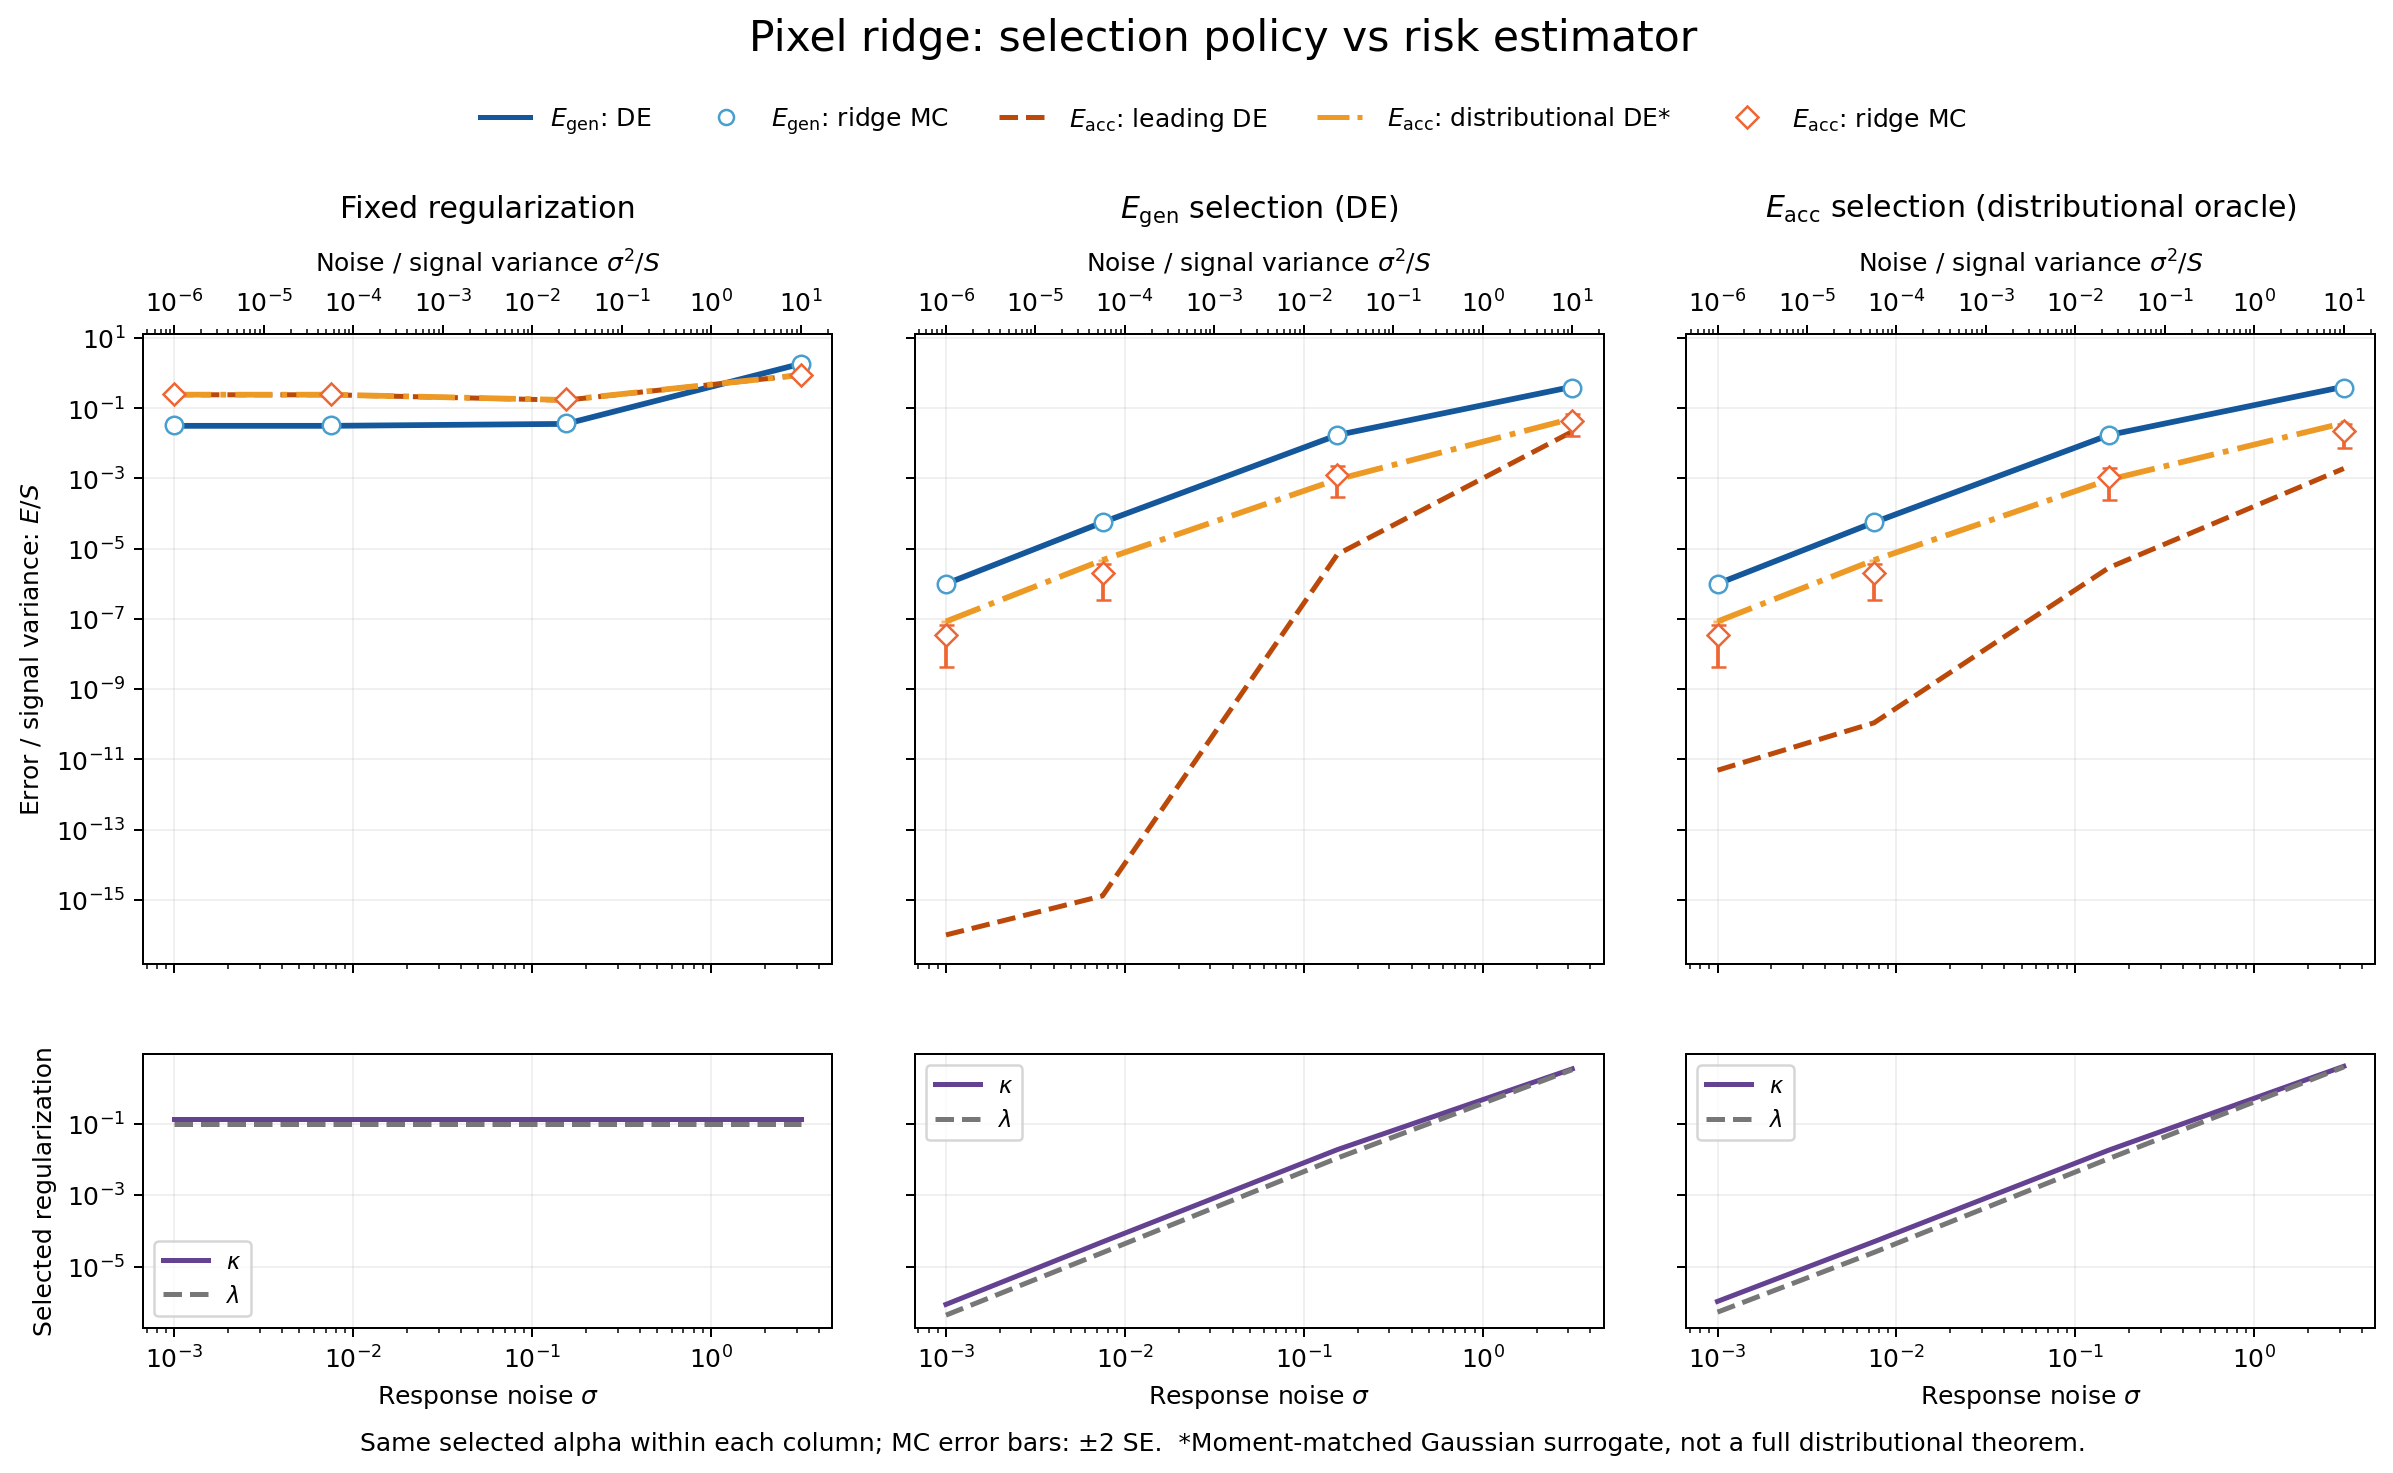

In [ ]:
from pathlib import Path
import sys, os, json, hashlib
os.environ.setdefault("MPLCONFIGDIR","/tmp/accentuationpredrmt-matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"rmt_core").is_dir())
sys.path.insert(0,str(ROOT))
from scripts import pixel_ridge_notebook_utils as u
from scripts.plot_pixel_ridge_estimator_comparison import prepare_tables, plot_comparison
threads=threadpool_limits(limits=2)
# Existing simulation cache; change these together when selecting another run.
RUN=ROOT/"notebooks/outputs/pixel_ridge/fa5aa82463c567f7"
G_RUN=RUN/"gaussian_23bf7b17a168"
OUT=ROOT/"notebooks/outputs/pixel_ridge/estimator_comparison"
OUT.mkdir(parents=True,exist_ok=True)
DRAWS=8192
EVALUATION_SEED=20260917
FORCE=False


In [ ]:
config=json.loads((RUN/"config.json").read_text())
print({k:config[k] for k in ["dataset","d","n","seed"]})
summary=pd.read_csv(RUN/"summary.csv")
gaussian=pd.read_csv(G_RUN/"summary.csv")
raw_mc=pd.read_csv(G_RUN/"ridge_mc_trials10_seed9017.csv")
s,beta=u.load_problem(ROOT,config["dataset"],config["d"],config["seed"])
n=int(config["n"])
digest=hashlib.sha256(str((DRAWS,EVALUATION_SEED)).encode())
for path in [RUN/"config.json",RUN/"summary.csv",G_RUN/"summary.csv",
             G_RUN/"ridge_mc_trials10_seed9017.csv",
             ROOT/"scripts/plot_pixel_ridge_estimator_comparison.py",
             ROOT/"scripts/pixel_ridge_notebook_utils.py"]:
    digest.update(path.read_bytes())
TABLE=OUT/("comparison_"+digest.hexdigest()[:12]+".csv")
if TABLE.exists() and not FORCE:
    table=pd.read_csv(TABLE)
    print("Loaded",TABLE)
else:
    table=prepare_tables(summary,gaussian,raw_mc,s,beta,n,DRAWS,EVALUATION_SEED)
    table.to_csv(TABLE,index=False)
print("Rows:",len(table),"MC trials per setting:",sorted(table.trials.unique()))
display(table[["policy","ratio","lam","kappa","E_gen","E_gen_mc",
               "E_acc","acc_distribution","E_acc_mc","trials"]])


In [ ]:
fig,axes=plot_comparison(table)
fig.savefig(OUT/"selection_vs_estimation.png",dpi=180,bbox_inches="tight")
fig.savefig(OUT/"selection_vs_estimation.pdf",bbox_inches="tight")
plt.show()
print("Figure:",OUT/"selection_vs_estimation.png")
